<a href="https://colab.research.google.com/github/vishakha122/dissertation/blob/main/dataset_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

# NOTEBOOK 2.5: Exploratory Data Analysis (EDA)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from google.colab import drive

drive.mount('/content/drive')

PROCESSED_PATH = '/content/drive/MyDrive/MIMIC-IV/processed/'

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

structured = pd.read_csv(PROCESSED_PATH + 'structured_preprocessed.csv')
notes      = pd.read_csv(PROCESSED_PATH + 'notes_preprocessed.csv')

with open(PROCESSED_PATH + 'feature_cols.json') as f:
    feature_cols = json.load(f)

with open(PROCESSED_PATH + 'label_mapping.json') as f:
    label_mapping = json.load(f)

# Merge for complete view
df = structured.merge(notes[['stay_id', 'text_truncated']],
                      on='stay_id', how='left')

print(f"Total ED stays: {len(df):,}")
print(f"Total features: {len(feature_cols)}\n")

Mounted at /content/drive
Total ED stays: 425,087
Total features: 29



TARGET VARIABLE: DISPOSITION
                   Count  Percentage
disposition_name                    
DISCHARGED        255378       60.08
ADMITTED          158010       37.17
OTHER              11699        2.75

Class Imbalance Ratio: 21.8:1
(Majority class is 21.8x larger than minority class)


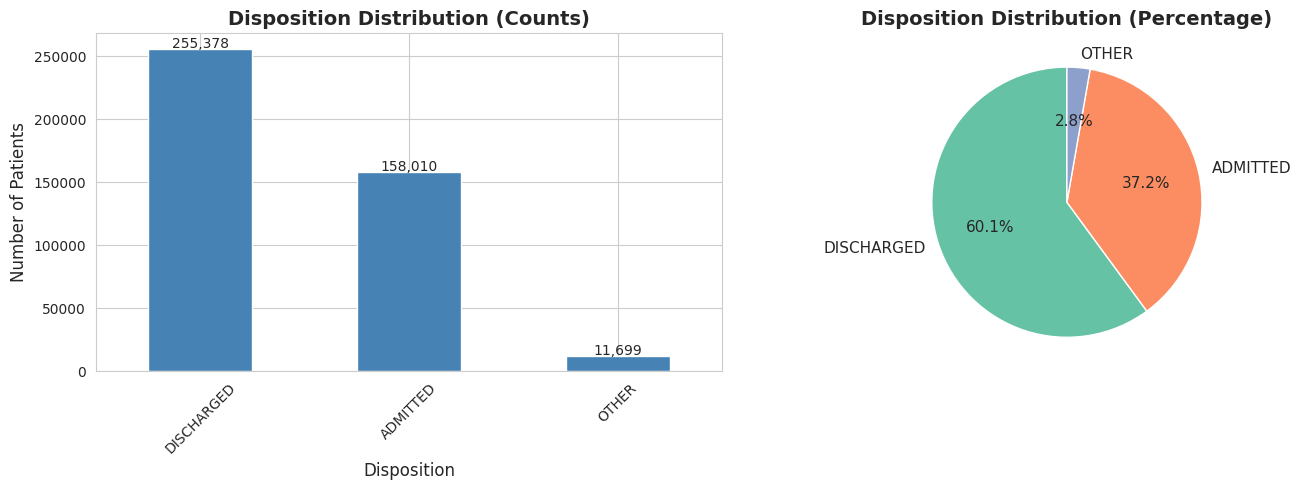

In [3]:
# 1. TARGET VARIABLE ANALYSIS (CRITICAL FOR YOUR PROBLEM)
inv_mapping = {v: k for k, v in label_mapping.items()}
df['disposition_name'] = df['disposition_label'].map(inv_mapping)

print("TARGET VARIABLE: DISPOSITION")
# Counts and percentages
disposition_counts = df['disposition_name'].value_counts()
disposition_pct = df['disposition_name'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count': disposition_counts,
    'Percentage': disposition_pct.round(2)
})
print(summary)

# Calculate imbalance ratio
max_class = disposition_counts.max()
min_class = disposition_counts.min()
imbalance_ratio = max_class / min_class
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.1f}:1")
print(f"(Majority class is {imbalance_ratio:.1f}x larger than minority class)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot with counts
disposition_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Disposition Distribution (Counts)', fontsize=14, weight='bold')
axes[0].set_xlabel('Disposition', fontsize=12)
axes[0].set_ylabel('Number of Patients', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(disposition_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# Pie chart with percentages
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
axes[1].pie(disposition_pct, labels=disposition_pct.index, autopct='%1.1f%%',
            startangle=90, colors=colors, textprops={'fontsize': 11})
axes[1].set_title('Disposition Distribution (Percentage)', fontsize=14, weight='bold')

plt.tight_layout()
plt.savefig(PROCESSED_PATH + 'eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# 2. MISSING VALUES ANALYSIS

print("MISSING VALUES ANALYSIS")
# Calculate missing percentages
missing = df[feature_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)

# Show top 20 features with most missing values
print("\nTop 20 Features with Missing Values:")
print(missing_pct.head(20).to_string())


MISSING VALUES ANALYSIS

Top 20 Features with Missing Values:
temperature         0.0
heartrate           0.0
resprate            0.0
o2sat               0.0
sbp                 0.0
dbp                 0.0
pain                0.0
acuity              0.0
temperature_mean    0.0
temperature_last    0.0
heartrate_mean      0.0
heartrate_max       0.0
resprate_mean       0.0
o2sat_mean          0.0
o2sat_min           0.0
sbp_mean            0.0
dbp_mean            0.0
num_vitals          0.0
num_diagnoses       0.0
num_medications     0.0


CLINICAL NOTES COVERAGE
Total ED stays:           425,087
Stays with clinical notes: 155,565 (36.6%)
Stays without notes:       269,522 (63.4%)

Notes Coverage by Disposition:
                  With Notes   Total  Coverage (%)
disposition_name                                  
ADMITTED              152085  158010          96.3
DISCHARGED               995  255378           0.4
OTHER                   2485   11699          21.2


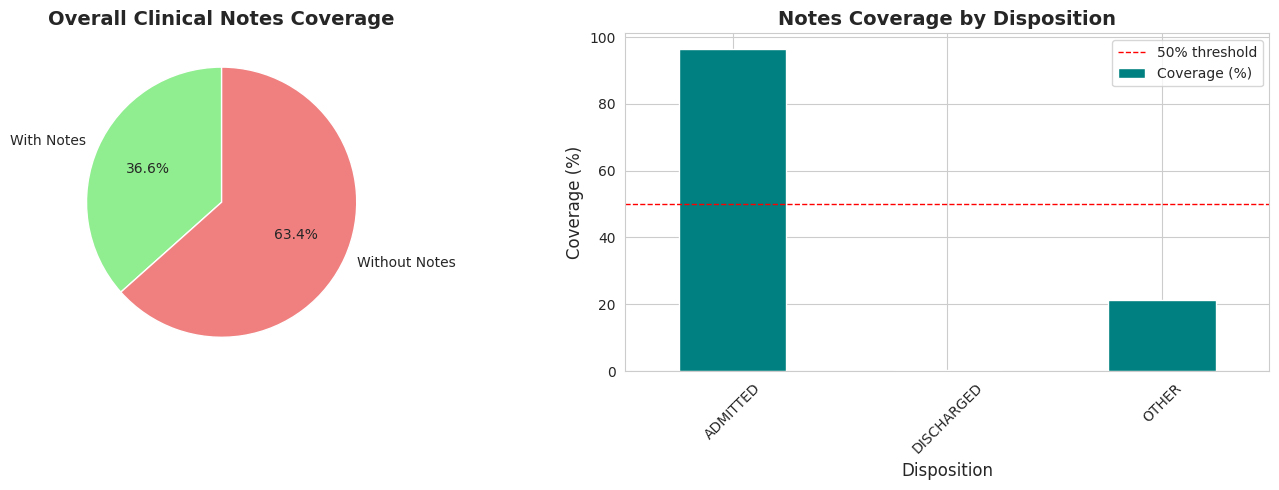

FINDING:
Over 50% of stays lack clinical notes


In [8]:
#CLINICAL NOTES COVERAGE

print("CLINICAL NOTES COVERAGE")

df['has_note'] = df['text_truncated'] != '[NO NOTE]'

total_stays = len(df)
with_notes = df['has_note'].sum()
without_notes = total_stays - with_notes

print(f"Total ED stays:           {total_stays:,}")
print(f"Stays with clinical notes: {with_notes:,} ({with_notes/total_stays*100:.1f}%)")
print(f"Stays without notes:       {without_notes:,} ({without_notes/total_stays*100:.1f}%)")

# Notes coverage by disposition
notes_by_disposition = df.groupby('disposition_name')['has_note'].agg(['sum', 'count'])
notes_by_disposition['percentage'] = (notes_by_disposition['sum'] / notes_by_disposition['count'] * 100).round(1)
notes_by_disposition.columns = ['With Notes', 'Total', 'Coverage (%)']

print("\nNotes Coverage by Disposition:")
print(notes_by_disposition.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall coverage
coverage_data = pd.Series([with_notes, without_notes],
                          index=['With Notes', 'Without Notes'])
axes[0].pie(coverage_data, labels=coverage_data.index, autopct='%1.1f%%',
            startangle=90, colors=['lightgreen', 'lightcoral'])
axes[0].set_title('Overall Clinical Notes Coverage', fontsize=14, weight='bold')

# Coverage by disposition
notes_by_disposition['Coverage (%)'].plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Notes Coverage by Disposition', fontsize=14, weight='bold')
axes[1].set_xlabel('Disposition', fontsize=12)
axes[1].set_ylabel('Coverage (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=50, color='red', linestyle='--', linewidth=1, label='50% threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROCESSED_PATH + 'eda_notes_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print("FINDING:")
if without_notes / total_stays > 0.5:
    print(f"Over 50% of stays lack clinical notes")

VITAL SIGNS DISTRIBUTION

Descriptive Statistics for Vital Signs:
       heartrate_mean  resprate_mean  o2sat_mean   sbp_mean   dbp_mean  temperature_mean
count       425087.00      425087.00   425087.00  425087.00  425087.00         425087.00
mean             0.00          -0.00       -0.00       0.00       0.00             -0.00
std              1.00           1.00        1.00       1.00       1.00              1.00
min             -5.11          -0.78      -24.07      -6.53      -0.68            -17.05
25%             -0.69          -0.07       -0.19      -0.67      -0.08             -0.04
50%             -0.09          -0.02        0.07      -0.10      -0.01              0.00
75%              0.57           0.03        0.32       0.57       0.05              0.05
max             32.65         640.53      250.76      15.47     463.36            154.56


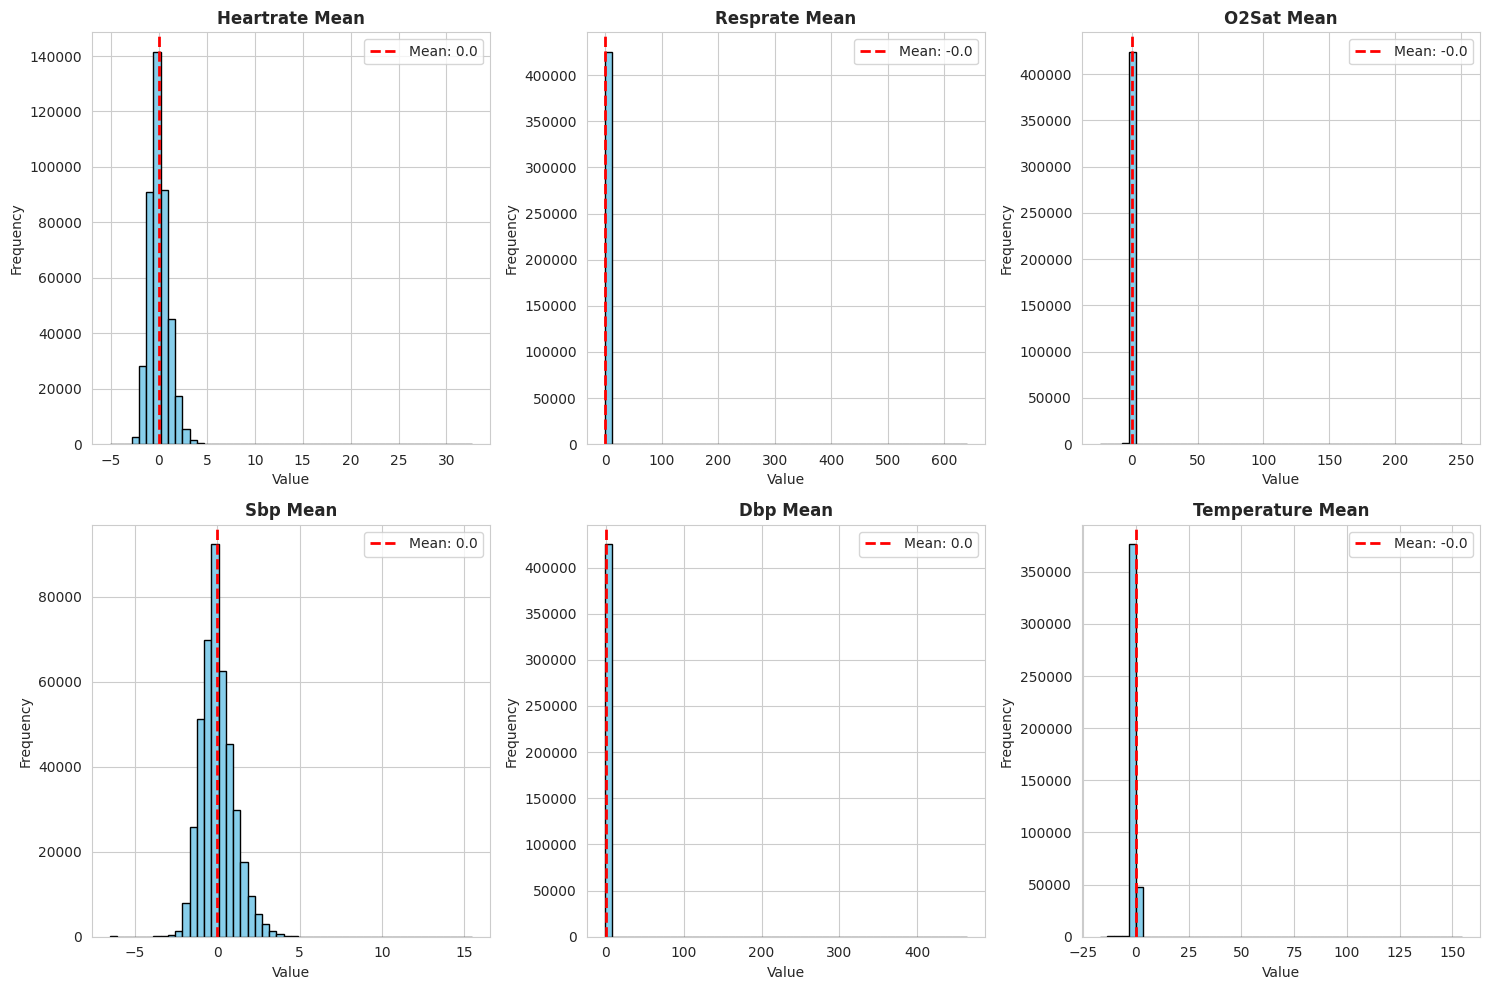

In [9]:
#VITAL SIGNS DISTRIBUTION

print("VITAL SIGNS DISTRIBUTION")

vital_cols = ['heartrate_mean', 'resprate_mean', 'o2sat_mean',
              'sbp_mean', 'dbp_mean', 'temperature_mean']

# Check which vitals exist in dataset
available_vitals = [col for col in vital_cols if col in df.columns]

print(f"\nDescriptive Statistics for Vital Signs:")
print(df[available_vitals].describe().round(2).to_string())

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(available_vitals):
    if i < len(axes):
        df[col].hist(bins=50, ax=axes[i], color='skyblue', edgecolor='black')
        axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, weight='bold')
        axes[i].set_xlabel('Value', fontsize=10)
        axes[i].set_ylabel('Frequency', fontsize=10)

        # Add mean line
        mean_val = df[col].mean()
        axes[i].axvline(mean_val, color='red', linestyle='--',
                       linewidth=2, label=f'Mean: {mean_val:.1f}')
        axes[i].legend()

# Hide unused subplots
for j in range(len(available_vitals), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(PROCESSED_PATH + 'eda_vitals_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

FEATURE CORRELATION ANALYSIS
Analyzing 22 numeric features

Top 15 Features Correlated with Disposition:
acuity             0.304752
num_vitals         0.243783
num_medications    0.203685
o2sat_min          0.153075
heartrate_max      0.148386
heartrate_mean     0.124231
num_diagnoses      0.092863
pain               0.085947
o2sat_mean         0.085556
resprate           0.060711
heartrate          0.054945
los_hours          0.037960
o2sat              0.020077
resprate_mean      0.019686
arrival_hour       0.016305


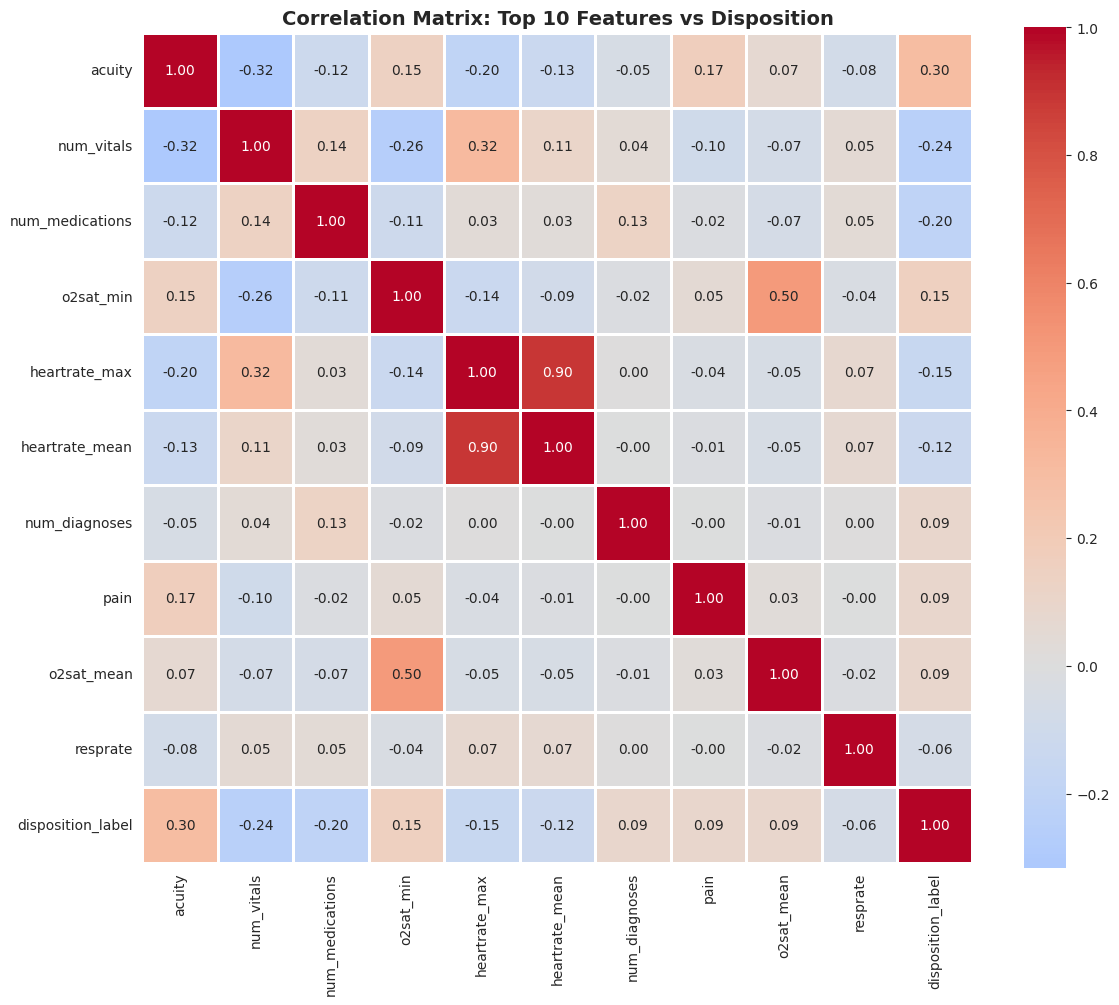

In [10]:
#FEATURE CORRELATION ANALYSIS

print("FEATURE CORRELATION ANALYSIS")

# Select numeric features only
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
print(f"Analyzing {len(numeric_features)} numeric features")

# Correlation with target
target_corr = df[numeric_features + ['disposition_label']].corr()['disposition_label'].drop('disposition_label')
top_corr = target_corr.abs().sort_values(ascending=False).head(15)

print("\nTop 15 Features Correlated with Disposition:")
print(top_corr.to_string())

# Heatmap of top correlated features
top_features = top_corr.index.tolist()[:10]
corr_matrix = df[top_features + ['disposition_label']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix: Top 10 Features vs Disposition',
          fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_PATH + 'eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

ACUITY AND DEMOGRAPHICS

Acuity Level Distribution:
acuity
-2.317612     24019
-0.896866    139411
 0.523881    232053
 1.944627     28504
 3.365373      1100

Acuity by Disposition (Mean):
disposition_name
DISCHARGED    0.30
OTHER        -0.31
ADMITTED     -0.46


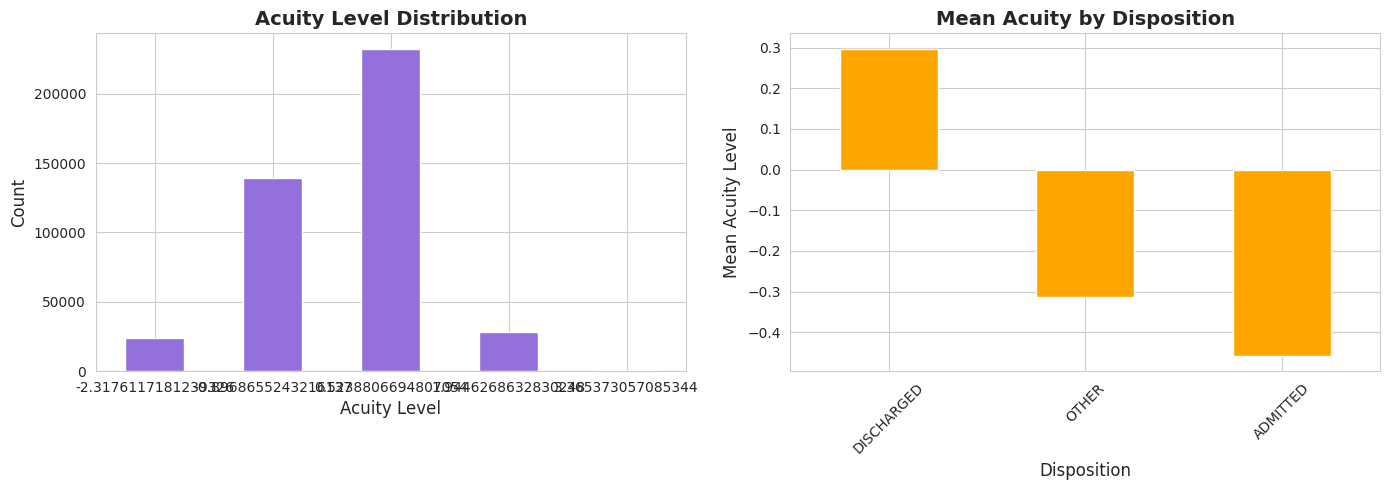


Gender Distribution:

gender_F:
gender_F
True     229898
False    195189

gender_M:
gender_M
False    229898
True     195189


In [12]:
#ACUITY AND DEMOGRAPHICS
print("ACUITY AND DEMOGRAPHICS")

# Acuity distribution (if available)
if 'acuity' in df.columns:
    print("\nAcuity Level Distribution:")
    acuity_dist = df['acuity'].value_counts().sort_index()
    print(acuity_dist.to_string())

    # Acuity by disposition
    print("\nAcuity by Disposition (Mean):")
    acuity_by_disp = df.groupby('disposition_name')['acuity'].mean().sort_values(ascending=False)
    print(acuity_by_disp.round(2).to_string())

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Acuity distribution
    acuity_dist.plot(kind='bar', ax=axes[0], color='mediumpurple')
    axes[0].set_title('Acuity Level Distribution', fontsize=14, weight='bold')
    axes[0].set_xlabel('Acuity Level', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].tick_params(axis='x', rotation=0)

    # Acuity by disposition
    acuity_by_disp.plot(kind='bar', ax=axes[1], color='orange')
    axes[1].set_title('Mean Acuity by Disposition', fontsize=14, weight='bold')
    axes[1].set_xlabel('Disposition', fontsize=12)
    axes[1].set_ylabel('Mean Acuity Level', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(PROCESSED_PATH + 'eda_acuity_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

# Gender distribution (if available)
gender_cols = [col for col in df.columns if 'gender' in col.lower()]
if gender_cols:
    print("\nGender Distribution:")
    for col in gender_cols[:2]:  # Show first 2 gender columns
        print(f"\n{col}:")
        print(df[col].value_counts().to_string())

LENGTH OF STAY ANALYSIS

Length of Stay Statistics (hours):
count    425087.00
mean          0.00
std           1.00
min          -4.51
25%          -0.55
50%          -0.26
75%           0.17
max          73.31

Length of Stay by Disposition:
                  Mean (hrs)  Median (hrs)  Std Dev
disposition_name                                   
ADMITTED                0.02         -0.14     0.76
DISCHARGED             -0.06         -0.34     1.01
OTHER                   0.97          0.17     2.33


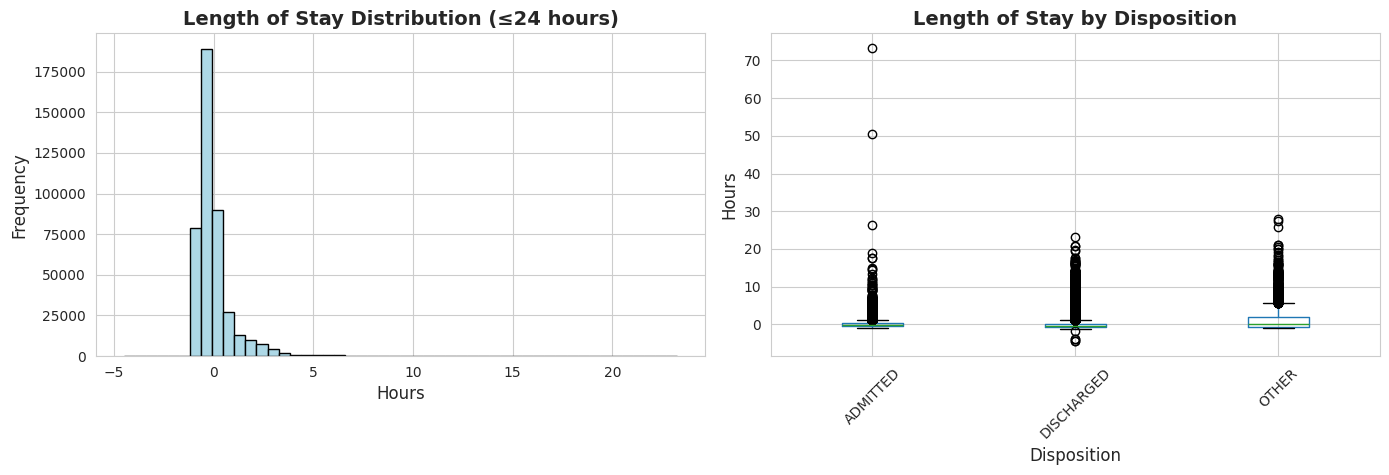

In [14]:
#LENGTH OF STAY ANALYSIS
print("LENGTH OF STAY ANALYSIS")

if 'los_hours' in df.columns:
    print(f"\nLength of Stay Statistics (hours):")
    print(df['los_hours'].describe().round(2).to_string())

    # LOS by disposition
    print("\nLength of Stay by Disposition:")
    los_by_disp = df.groupby('disposition_name')['los_hours'].agg(['mean', 'median', 'std']).round(2)
    los_by_disp.columns = ['Mean (hrs)', 'Median (hrs)', 'Std Dev']
    print(los_by_disp.to_string())

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Overall LOS distribution (capped at 24 hours for visibility)
    df[df['los_hours'] <= 24]['los_hours'].hist(bins=50, ax=axes[0],
                                                  color='lightblue', edgecolor='black')
    axes[0].set_title('Length of Stay Distribution (≤24 hours)', fontsize=14, weight='bold')
    axes[0].set_xlabel('Hours', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)

    # LOS by disposition (boxplot)
    df.boxplot(column='los_hours', by='disposition_name', ax=axes[1])
    axes[1].set_title('Length of Stay by Disposition', fontsize=14, weight='bold')
    axes[1].set_xlabel('Disposition', fontsize=12)
    axes[1].set_ylabel('Hours', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)
    plt.suptitle('')  # Remove default title

    plt.tight_layout()
    plt.savefig(PROCESSED_PATH + 'eda_length_of_stay.png', dpi=150, bbox_inches='tight')
    plt.show()

In [15]:
# KEY FINDINGS SUMMARY

print("KEY FINDINGS & RECOMMENDATIONS")
findings = f"""
1. CLASS IMBALANCE (CRITICAL):
   - Imbalance ratio: {imbalance_ratio:.1f}:1
   - DISCHARGED dominates at {disposition_pct['DISCHARGED']:.1f}%
   - TRANSFER and OTHER are severely underrepresented
   → RECOMMENDATION: Use class weighting in loss function

2. CLINICAL NOTES COVERAGE:
   - {without_notes/total_stays*100:.1f}% of stays lack clinical notes
   - Coverage varies by disposition
   → RECOMMENDATION: [NO NOTE] placeholder approach is appropriate

3. MODEL EVALUATION METRICS:
   - Standard accuracy is misleading with this imbalance
   → RECOMMENDATION: Use macro F1-score, per-class recall, and confusion matrix

4. BASELINE PERFORMANCE:
   - A dummy classifier predicting only DISCHARGED would achieve {disposition_pct['DISCHARGED']:.1f}% accuracy
   → Your model MUST exceed this to be meaningful

5. TRAINING STRATEGY:
   - Use weighted CrossEntropyLoss with class weights
   - Monitor per-class metrics during training
   - Consider oversampling minority classes (TRANSFER, OTHER)
"""

print(findings)

# Save summary to file
with open(PROCESSED_PATH + 'eda_summary.txt', 'w') as f:
    f.write("MIMIC-IV ED DISPOSITION PREDICTION - EDA SUMMARY\n")
    f.write("="*60 + "\n\n")
    f.write(findings)

print(" EDA complete!")
print(f"All visualizations saved to: {PROCESSED_PATH}")
print(" Summary saved to: eda_summary.txt")

KEY FINDINGS & RECOMMENDATIONS

1. CLASS IMBALANCE (CRITICAL):
   - Imbalance ratio: 21.8:1
   - DISCHARGED dominates at 60.1%
   - TRANSFER and OTHER are severely underrepresented
   → RECOMMENDATION: Use class weighting in loss function

2. CLINICAL NOTES COVERAGE:
   - 63.4% of stays lack clinical notes
   - Coverage varies by disposition
   → RECOMMENDATION: [NO NOTE] placeholder approach is appropriate

3. MODEL EVALUATION METRICS:
   - Standard accuracy is misleading with this imbalance
   → RECOMMENDATION: Use macro F1-score, per-class recall, and confusion matrix

4. BASELINE PERFORMANCE:
   - A dummy classifier predicting only DISCHARGED would achieve 60.1% accuracy
   → Your model MUST exceed this to be meaningful

5. TRAINING STRATEGY:
   - Use weighted CrossEntropyLoss with class weights
   - Monitor per-class metrics during training
   - Consider oversampling minority classes (TRANSFER, OTHER)

 EDA complete!
All visualizations saved to: /content/drive/MyDrive/MIMIC-IV/pro